# Question 1

## 1. Graph Representation:

In [1]:
import pandas as pd
import networkx as nx



1. Construct a graph using NetworkX where cities act as nodes and distances actas weighted edges.

In [2]:
file = pd.read_csv('indian-cities-dataset.csv')

In [3]:
source_node = file['Origin']
dest_node = file['Destination']
weig = file['Distance']


2. Visualize the graph.

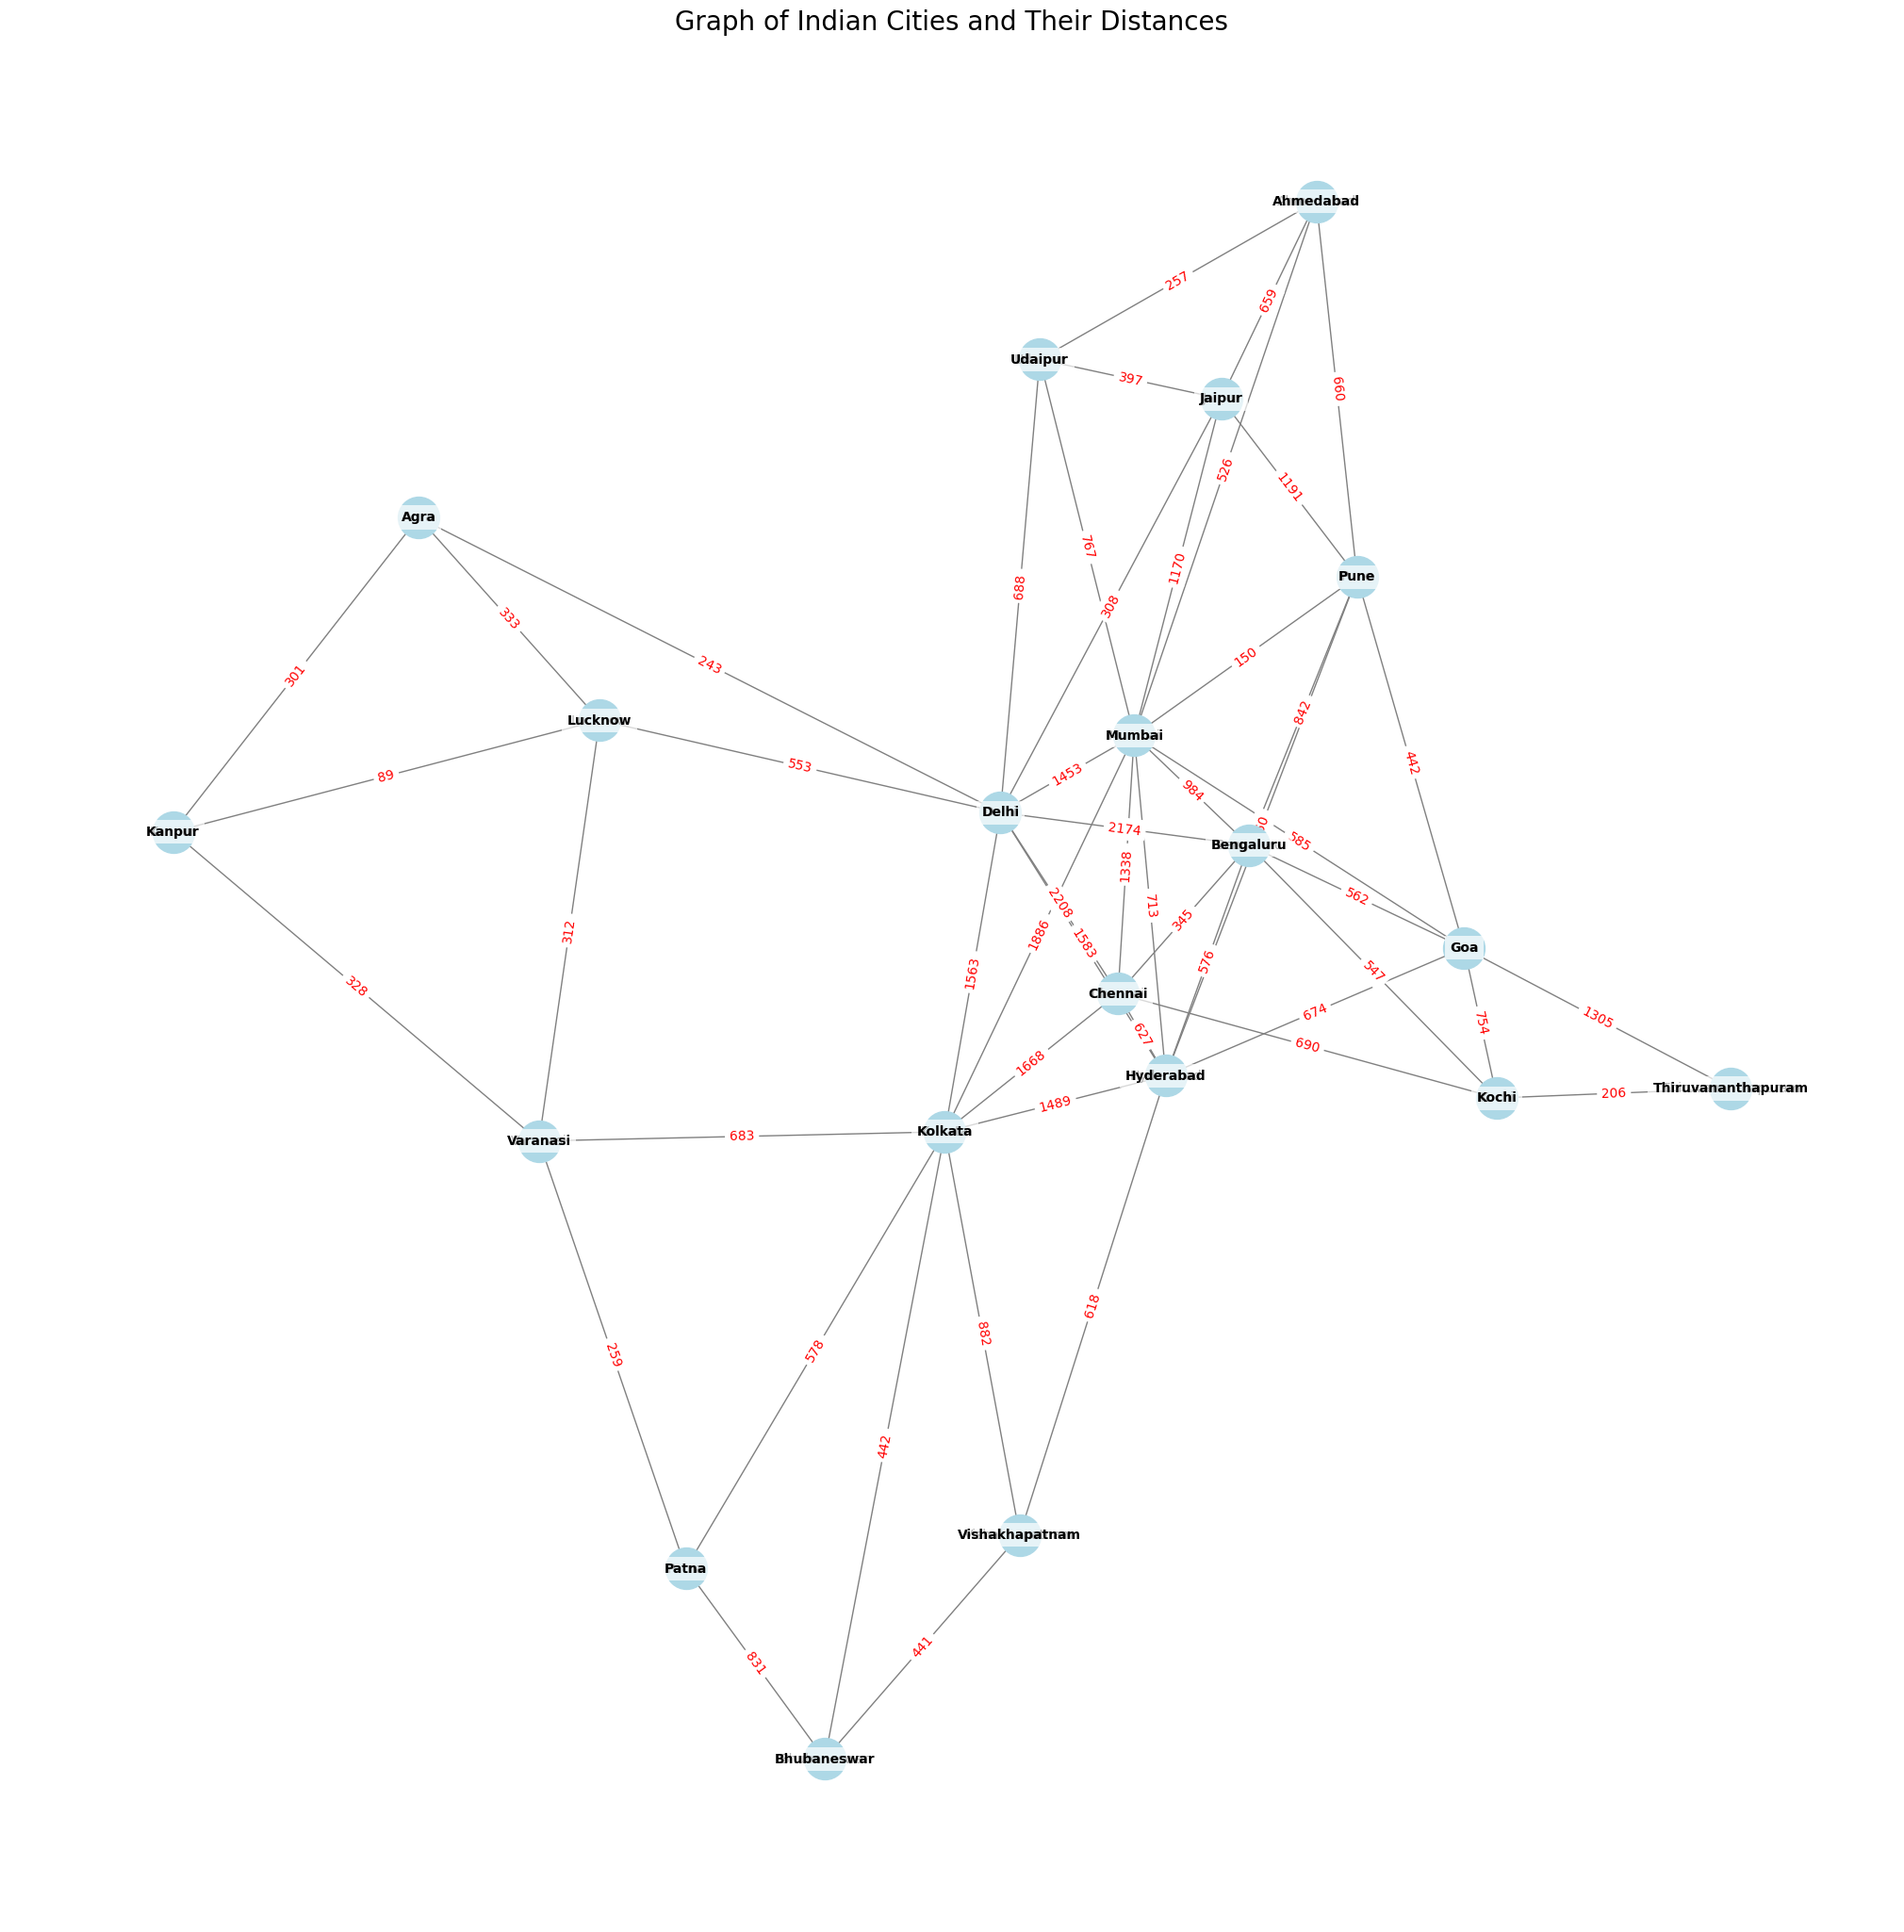

In [4]:
import matplotlib.pyplot as plt

# creates a graph (empty)
graph = nx.Graph()

# putting everything i.e nodes and their weights in graph
for i in range(len(file)):
    graph.add_edge(source_node[i], dest_node[i], weight = weig[i])

# Set figure size
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(graph, k=0.8, seed=42)

# Generate node and edge labels
labels = {node: node for node in graph.nodes}
edge_labels = nx.get_edge_attributes(graph, 'weight')

# better visibility settings
nx.draw(graph, pos, with_labels=True, node_size=1000, node_color='lightblue', font_size=10, edge_color='gray', width=1)
nx.draw_networkx_labels(graph, pos, labels, font_size=10, font_color='black', font_weight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
nx.draw_networkx_edge_labels(graph, pos, edge_labels, font_size=10, font_color='red')

plt.title("Graph of Indian Cities and Their Distances", fontsize=20)
plt.show()


## 2. Graph Analysis:

1. Compute and display the shortest path between two user-defined cities.

In [13]:
city1 = input("Enter the source city: ").capitalize()
city2 = input("Enter the destination city: ").capitalize()

# If city not exists dont search, else find shortest path b/2 2 cities
if city1 not in graph or city2 not in graph:
    print(f"One or both cities ({city1}, {city2}) are not in the graph.")
else:
    if nx.has_path(graph, city1, city2):
        path = nx.shortest_path(graph, source=city1, target=city2, weight='weight')
        path_length = nx.shortest_path_length(graph, source=city1, target=city2, weight='weight')
        print(f"Shortest path from {city1} to {city2}: {path} with distance {path_length}\n\n\n\n\n")
    else:
        print(f"No path exists between {city1} and {city2}.\n\n\n\n\n")


Enter the source city:  goa
Enter the destination city:  delhi


Shortest path from Goa to Delhi: ['Goa', 'Pune', 'Jaipur', 'Delhi'] with distance 1941







2. Find the city with the highest number of connections.

In [6]:
print("All the cities and their Connections\n")
print(graph.degree,'\n')
# graph degree gives all the cities and their totoal occurences with other cities


# here find the city with max value and then return it's name
most_connected_city = max(graph.degree, key=lambda x: x[1])[0]
print(f"City with the highest number of connections: {most_connected_city}")


All the cities and their Connections

[('Agra', 3), ('Delhi', 9), ('Lucknow', 4), ('Kanpur', 3), ('Ahmedabad', 4), ('Mumbai', 10), ('Pune', 6), ('Jaipur', 5), ('Udaipur', 4), ('Bengaluru', 7), ('Hyderabad', 8), ('Chennai', 6), ('Goa', 6), ('Bhubaneswar', 3), ('Kolkata', 8), ('Vishakhapatnam', 3), ('Patna', 3), ('Kochi', 4), ('Thiruvananthapuram', 2), ('Varanasi', 4)] 

City with the highest number of connections: Mumbai


3. Calculate the average shortest path length between all connected cities.

In [7]:

# using networkx built in function to calculate and print the average shortest path
if nx.is_connected(graph):
    avg_path_length = nx.average_shortest_path_length(graph, weight='weight')
    print(f"Average shortest path length between all connected cities: {avg_path_length:.2f}\n\n\n\n\n")


Average shortest path length between all connected cities: 1567.12







## 3. Statistical Calculations:

1. Find the longest and shortest direct connection in the dataset.

In [8]:
# using somple min max functions to calculate longest and shortest path
longest_connection = max(zip(weig, source_node, dest_node))
shortest_connection = min(zip(weig, source_node, dest_node))


print(f"Longest direct connection: {longest_connection[1]} to {longest_connection[2]} with distance {longest_connection[0]}")
print(f"Shortest direct connection: {shortest_connection[1]} to {shortest_connection[2]} with distance {shortest_connection[0]}\n\n\n\n\n")


Longest direct connection: Delhi to Chennai with distance 2208
Shortest direct connection: Lucknow to Kanpur with distance 89







2. Calculate the average, median, and standard deviation of all distances.

In [9]:
import numpy as np

# 2. Calculating average, median, and standard deviation of all distances
print(f"Average distance: {np.mean(weig):.2f}")
print(f"Median distance: {np.median(weig):.2f}")
print(f"Standard deviation of distances: {np.std(weig):.2f}\n\n\n\n\n")


Average distance: 711.60
Median distance: 578.00
Standard deviation of distances: 477.68







## 4. Advanced Operations:

1. Identify if the graph is connected.

In [10]:
# netwotkx function :: Is connected ()

is_connected = nx.is_connected(graph)
print(f"Is the graph connected? {is_connected}\n\n\n\n\n")

Is the graph connected? True







2. Find all possible paths between two given cities.

In [11]:
from itertools import islice

def find_and_display_paths(graph, start_city, end_city, max_paths=5):
    # Check if cities exist in graph
    if start_city not in graph or end_city not in graph:
        print(f"Error: One or both cities ({start_city}, {end_city}) not found in map")
        return

    
    # Find all paths
    paths = list(nx.all_simple_paths(graph, start_city, end_city))
    total_paths = len(paths)

    
    # Display results
    print(f"\nFound {total_paths} paths from {start_city} to {end_city}")

    
    if total_paths == 0:
        return

        
    # Show paths up to max_paths limit
    paths_to_show = paths[:max_paths]

    
    # enumerates: It returns pairs of (index, item) as you loop through the items an adds a counter to each entry.
    for i, path in enumerate(paths_to_show, start=1):
        route = " -> ".join(path)
        print(f"Path {i}: {route}")

    
    # Show how many more paths exist
    if total_paths > max_paths:
        remaining = total_paths - max_paths
        print(f"\nAnd {remaining} more paths...\n\n\n\n\n\n\n")


# Get user input
start = input("Enter starting city: ").capitalize()
end = input("Enter destination city: ").capitalize()

# Show paths (limited to 5 for readability)
find_and_display_paths(graph, start, end, max_paths=5)

Enter starting city:  goa
Enter destination city:  delhi



Found 70817 paths from Goa to Delhi
Path 1: Goa -> Bengaluru -> Pune -> Ahmedabad -> Mumbai -> Chennai -> Hyderabad -> Delhi
Path 2: Goa -> Bengaluru -> Pune -> Ahmedabad -> Mumbai -> Chennai -> Hyderabad -> Kolkata -> Bhubaneswar -> Patna -> Varanasi -> Kanpur -> Agra -> Delhi
Path 3: Goa -> Bengaluru -> Pune -> Ahmedabad -> Mumbai -> Chennai -> Hyderabad -> Kolkata -> Bhubaneswar -> Patna -> Varanasi -> Kanpur -> Agra -> Lucknow -> Delhi
Path 4: Goa -> Bengaluru -> Pune -> Ahmedabad -> Mumbai -> Chennai -> Hyderabad -> Kolkata -> Bhubaneswar -> Patna -> Varanasi -> Kanpur -> Lucknow -> Agra -> Delhi
Path 5: Goa -> Bengaluru -> Pune -> Ahmedabad -> Mumbai -> Chennai -> Hyderabad -> Kolkata -> Bhubaneswar -> Patna -> Varanasi -> Kanpur -> Lucknow -> Delhi

And 70812 more paths...









3. Convert the graph into an adjacency matrix and display it.

In [12]:
# 3. Convert the graph into an adjacency matrix and display it with column names
nodes_sorted = sorted(graph.nodes())

adj_matrix = pd.DataFrame(nx.to_numpy_array(graph, nodelist=nodes_sorted), index=nodes_sorted, columns=nodes_sorted)

pd.set_option("display.max_columns", None)

print("Adjacency Matrix:")

print(adj_matrix)


Adjacency Matrix:
                     Agra  Ahmedabad  Bengaluru  Bhubaneswar  Chennai   Delhi  \
Agra                  0.0        0.0        0.0          0.0      0.0   243.0   
Ahmedabad             0.0        0.0        0.0          0.0      0.0     0.0   
Bengaluru             0.0        0.0        0.0          0.0    345.0  2174.0   
Bhubaneswar           0.0        0.0        0.0          0.0      0.0     0.0   
Chennai               0.0        0.0      345.0          0.0      0.0  2208.0   
Delhi               243.0        0.0     2174.0          0.0   2208.0     0.0   
Goa                   0.0        0.0      562.0          0.0      0.0     0.0   
Hyderabad             0.0        0.0      576.0          0.0    627.0  1583.0   
Jaipur                0.0      659.0        0.0          0.0      0.0   308.0   
Kanpur              301.0        0.0        0.0          0.0      0.0     0.0   
Kochi                 0.0        0.0      547.0          0.0    690.0     0.0   
Kolkata   